In [ ]:
import os

os.environ["KAGGLE_USERNAME"] = "redacted"
os.environ["KAGGLE_KEY"] = "redacted"

In [2]:
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset


Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
  0% 0.00/41.0M [00:00<?, ?B/s]
100% 41.0M/41.0M [00:00<00:00, 673MB/s]


In [3]:
import zipfile

with zipfile.ZipFile("fake-and-real-news-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data")

In [4]:
import pandas as pd

fake = pd.read_csv("data/Fake.csv")
real = pd.read_csv("data/True.csv")

fake["label"] = 0   # Fake
real["label"] = 1   # Real

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df["text"] = df["title"] + " " + df["text"]
df = df[["text", "label"]]

In [5]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

In [6]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "Pulk17/Fake-News-Detection"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [7]:
def tokenize(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

test_encodings = tokenize(test_texts)
test_encodings = {k: v.to(device) for k, v in test_encodings.items()}

In [8]:
import numpy as np

def shap_model(texts):
    # SHAP may pass numpy arrays of dtype object
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    if isinstance(texts, str):
        texts = [texts]

    # Final safety check
    texts = [str(t) for t in texts]

    encodings = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    )

    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings)

    return outputs.logits.cpu().numpy()

In [9]:
import shap


In [10]:
explainer = shap.Explainer(
    shap_model,
    masker=shap.maskers.Text()
)

In [11]:
shap_values = explainer(test_texts[:50])


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   6%|▌         | 3/50 [00:16<01:26,  1.85s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  18%|█▊        | 9/50 [00:40<02:29,  3.64s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  22%|██▏       | 11/50 [00:52<03:08,  4.82s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  42%|████▏     | 21/50 [01:31<01:46,  3.66s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  48%|████▊     | 24/50 [01:46<01:52,  4.32s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  58%|█████▊    | 29/50 [02:10<01:18,  3.72s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  60%|██████    | 30/50 [02:17<01:38,  4.91s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  64%|██████▍   | 32/50 [02:28<01:28,  4.92s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  68%|██████▊   | 34/50 [02:38<01:17,  4.85s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  72%|███████▏  | 36/50 [02:49<01:07,  4.85s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  84%|████████▍ | 42/50 [03:15<00:28,  3.59s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  86%|████████▌ | 43/50 [03:22<00:31,  4.54s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  92%|█████████▏| 46/50 [03:39<00:19,  4.77s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  96%|█████████▌| 48/50 [03:48<00:09,  4.52s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 51it [04:07,  4.94s/it]


In [12]:
i = 0  # sample index
shap.initjs()

plots_html = shap.plots.text(shap_values, display=False)
with open("shap_text.html", "w", encoding="utf-8") as f:
    f.write(plots_html)

In [13]:
def tokens_to_words(tokens, values):
    words = []
    word_values = []

    current_word = ""
    current_value = 0.0

    for tok, val in zip(tokens, values):
        if tok.strip() == "":
            continue

        # BERT-style continuation token
        if tok.startswith("##"):
            current_word += tok[2:]
            current_value += val
        else:
            if current_word != "":
              words.append(current_word)
              word_values.append(current_value)

            current_word = tok
            current_value = val

    if current_word != "":
        words.append(current_word)
        word_values.append(current_value)

    return words, word_values

In [14]:
def top_words(shap_values, class_idx=1, top_k=10, n_samples=10):
    dfs = []

    for sample_idx in range(n_samples):
        values = shap_values.values[sample_idx][:, class_idx]
        tokens = shap_values.data[sample_idx]

        words, word_values = tokens_to_words(tokens, values)

        df = pd.DataFrame({
            "word": words,
            "importance": word_values
        })

        df["abs"] = df.importance.abs()
        df = df.sort_values("abs", ascending=False).head(top_k)

        dfs.append(df)

    return dfs

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

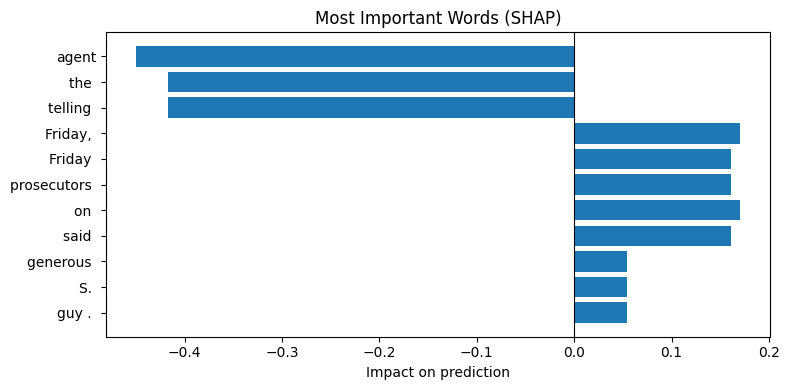

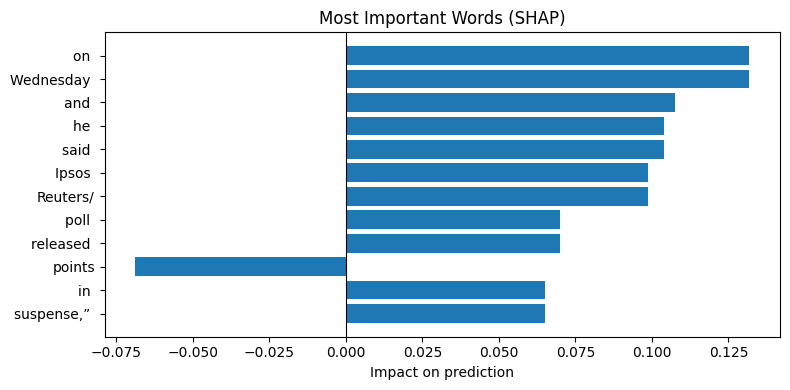

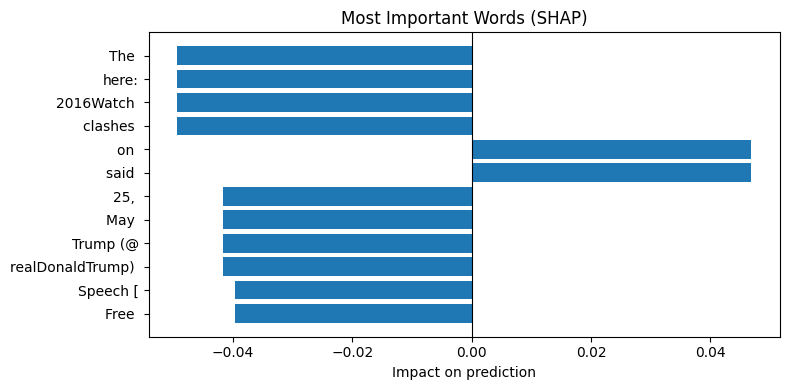

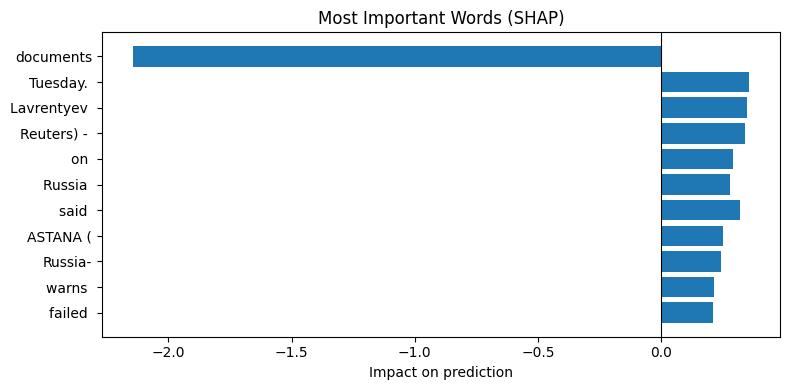

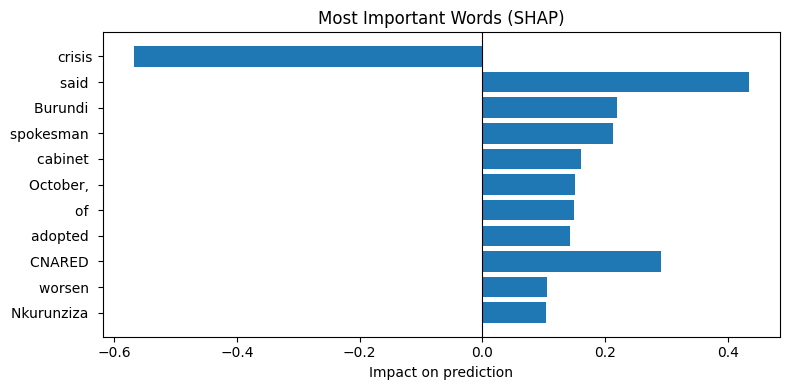

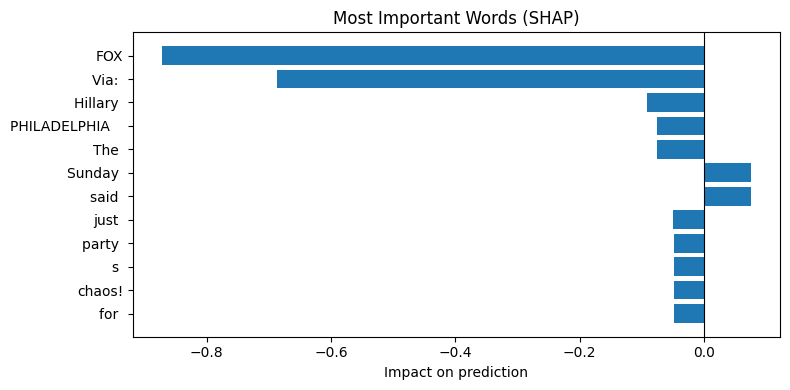

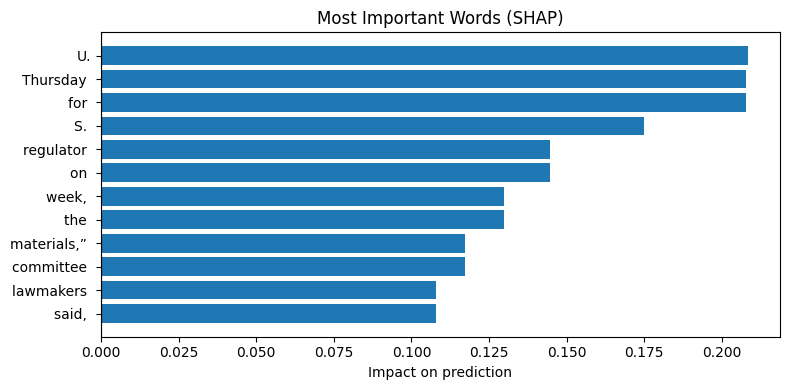

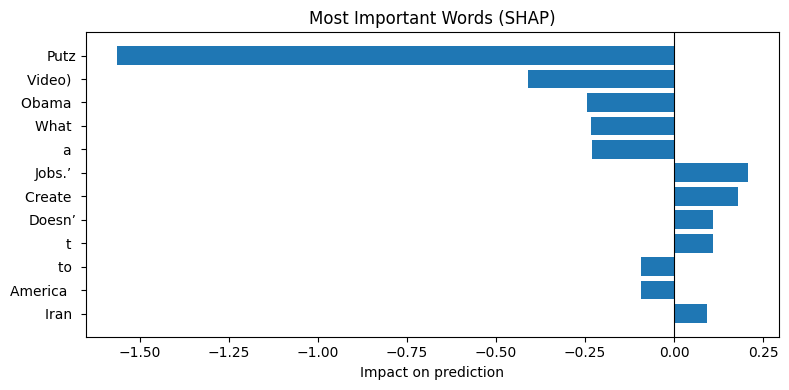

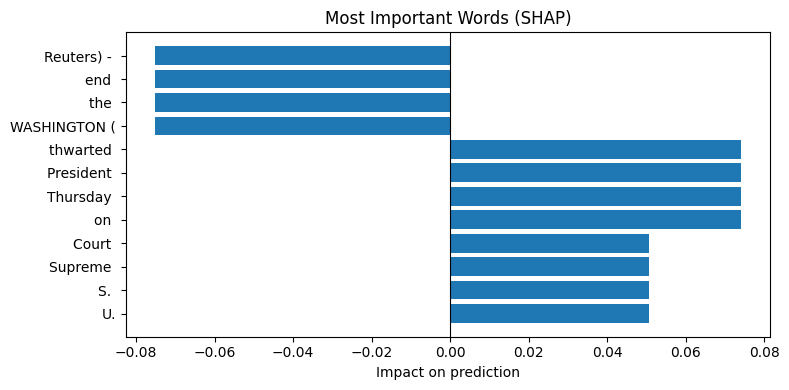

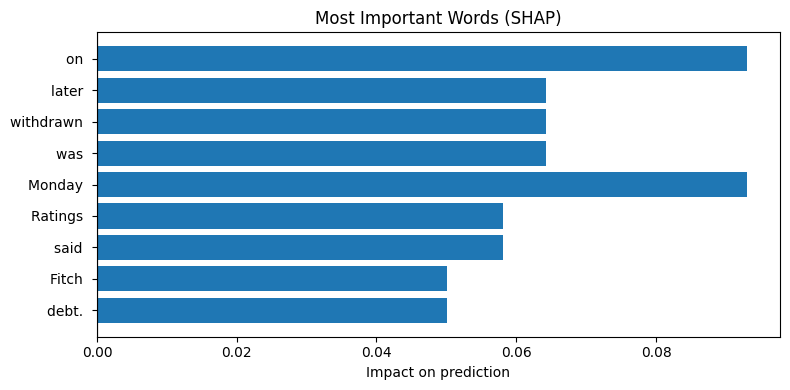

In [16]:
dfs = top_words(shap_values, top_k=12)

for i in range(10):
    plt.figure(figsize=(8, 4))
    plt.barh(
        dfs[i].word[::-1],
        dfs[i].importance[::-1]
    )
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Most Important Words (SHAP)")
    plt.xlabel("Impact on prediction")
    plt.tight_layout()
    plt.show()

In [17]:
print(dfs)

[             word  importance       abs
756         agent   -0.449938  0.449938
755          the    -0.417474  0.417474
754      telling    -0.417474  0.417474
558      Friday,     0.170426  0.170426
557           on     0.170426  0.170426
63        Friday     0.161051  0.161051
60   prosecutors     0.161051  0.161051
62            on     0.161051  0.161051
61          said     0.161051  0.161051
56      generous     0.054324  0.054324
59            S.     0.054324  0.054324
57         guy .     0.054324  0.054324,             word  importance       abs
60           on     0.131799  0.131799
61    Wednesday     0.131799  0.131799
62          and     0.107583  0.107583
586          he     0.104059  0.104059
587        said     0.104059  0.104059
57        Ipsos     0.098720  0.098720
56      Reuters/    0.098720  0.098720
58         poll     0.069915  0.069915
59     released     0.069915  0.069915
645       points   -0.068822  0.068822
584          in     0.064978  0.064978
585  suspe

In [18]:
import re
import nltk
from nltk.corpus import wordnet as wn

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [19]:
def predict_label_and_prob(text):
    enc = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        logits = model(**enc).logits
        probs = torch.softmax(logits, dim=-1)[0]

    label = torch.argmax(probs).item()
    return label, probs[label].item()

In [20]:
def strongest_word(shap_values, sample_idx, importance):
    pred_class = shap_values.values[sample_idx].mean(axis=0).argmax()

    values = shap_values.values[sample_idx][:, pred_class]
    tokens = shap_values.data[sample_idx]

    words, word_values = tokens_to_words(tokens, values)

    df = pd.DataFrame({
        "word": words,
        "importance": word_values
    })

    # strongest aligned = largest positive contribution
    df = df.sort_values("importance", ascending=False).reset_index(drop=True)

    if importance >= len(df):
        return None, None, pred_class   # <- signal "no more words"

    return (
        df.iloc[importance]["word"],
        df.iloc[importance]["importance"],
        pred_class
    )



In [21]:
import random


In [22]:
def delete_word(text, target_word):
    pattern = rf"\b{re.escape(target_word)}\b"
    new_text, n = re.subn(pattern, "", text)
    new_text = re.sub(r"\s+", " ", new_text).strip()
    return new_text

def delete_number_of_words(num_words_to_delete, num_examples, test_texts):
    results = []

    for i in range(0, num_examples):
      original_text = test_texts[i]

      # Original prediction
      orig_label, orig_conf = predict_label_and_prob(original_text)

      local_result = []

      current_text = original_text # Initialize current_text for sequential deletion

      for j in range(0, num_words_to_delete):
        word, shap_score, shap_class = strongest_word(shap_values, i, j)

        if word is None:
            break  # no more words to try

        current_text = delete_word(current_text, word)
        del_label, del_conf = predict_label_and_prob(current_text)


        local_result.append({
            "num_words_deleted": j,
            "original_label": orig_label,
            "original_conf": orig_conf,
            "target_word": word,
            "shap_score": shap_score,
            "deleted_label": del_label,
            "deleted_conf": del_conf,
            "text_after_deletion": current_text # Corrected key here
        })

      results.append(local_result)

    return results

delete_results = delete_number_of_words(num_words_to_delete=40, num_examples=30, test_texts=test_texts)

In [23]:
label_change_summary = []

# delete_results is a list of lists of dictionaries
for sample_idx, sample_results in enumerate(delete_results):
    # Get the original predicted label (at step 0)
    # The first item in sample_results corresponds to the original text (num_words_deleted = 0)
    original_label = sample_results[0]["original_label"]
    original_conf = sample_results[0]["original_conf"]

    num_words_deleted_until_change = "Never changed"
    new_predicted_label_after_change = original_label

    # Iterate through deletion steps (starting from the first deletion, which is step 1 logically, but num_words_deleted = 0 in the results)
    for step_data in sample_results:
        if step_data["deleted_label"] != original_label:
            num_words_deleted_until_change = step_data["num_words_deleted"] + 1 # +1 because num_words_deleted is 0-indexed for the first deleted word
            new_predicted_label_after_change = step_data["deleted_label"]
            break # Found the first label change, so break

    label_change_summary.append({
        "original_sample_idx": sample_idx,
        "original_predicted_label": original_label,
        "original_confidence": original_conf,
        "num_words_deleted_until_change": num_words_deleted_until_change,
        "new_predicted_label_after_change": new_predicted_label_after_change
    })

# Convert the summary list into a pandas DataFrame
df_label_change_summary = pd.DataFrame(label_change_summary)

# Print a descriptive header
print("Summary of Label Changes After Iterative Word Deletion:")

# Display the DataFrame, replacing numerical labels with 'FAKE'/'REAL'
df_display_summary = df_label_change_summary.copy()
df_display_summary["original_predicted_label"] = df_display_summary["original_predicted_label"].replace({0: "FAKE", 1: "REAL"})
df_display_summary["new_predicted_label_after_change"] = df_display_summary["new_predicted_label_after_change"].replace({0: "FAKE", 1: "REAL"})
display(df_display_summary)

Summary of Label Changes After Iterative Word Deletion:


,original_sample_idx,original_predicted_label,original_confidence,num_words_deleted_until_change,new_predicted_label_after_change
0,0,REAL,0.999619,7,FAKE
1,1,REAL,0.999847,Never changed,REAL
2,2,FAKE,0.999745,Never changed,FAKE
3,3,REAL,0.999856,28,FAKE
4,4,REAL,0.999846,Never changed,REAL
5,5,FAKE,0.999794,Never changed,FAKE
6,6,REAL,0.999854,Never changed,REAL
7,7,FAKE,0.995417,Never changed,FAKE
8,8,REAL,0.999842,Never changed,REAL
9,9,REAL,0.999857,Never changed,REAL


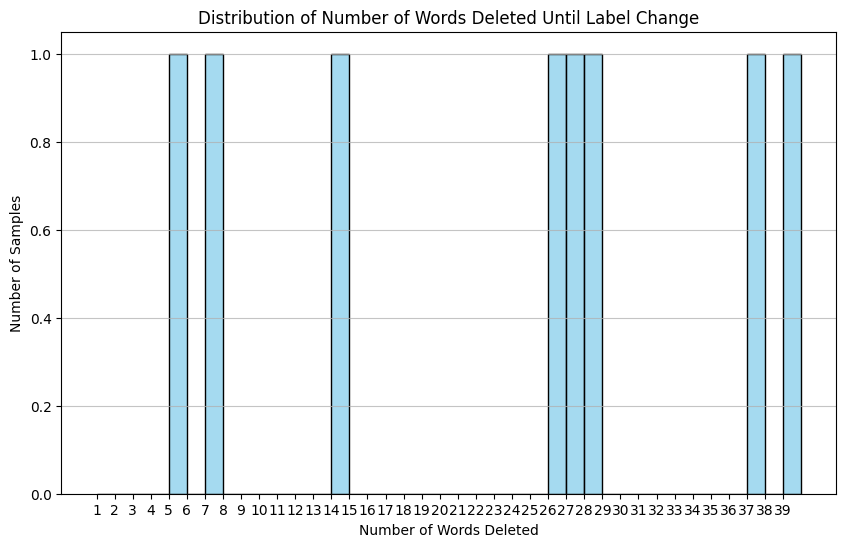

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize Label Change Distribution
# Filter out samples where the label never changed for numerical plotting
plot_data = df_label_change_summary[df_label_change_summary["num_words_deleted_until_change"] != "Never changed"].copy()

if not plot_data.empty:
    plot_data["num_words_deleted_until_change"] = plot_data["num_words_deleted_until_change"].astype(int)

    plt.figure(figsize=(10, 6))
    sns.histplot(plot_data["num_words_deleted_until_change"], bins=range(1, plot_data["num_words_deleted_until_change"].max() + 2), kde=False, color="skyblue", edgecolor="black")
    plt.title("Distribution of Number of Words Deleted Until Label Change")
    plt.xlabel("Number of Words Deleted")
    plt.ylabel("Number of Samples")
    plt.xticks(range(1, plot_data["num_words_deleted_until_change"].max() + 1))
    plt.grid(axis="y", alpha=0.75)
    plt.show()
else:
    print("No label changes were observed within the 'max_words' limit for any of the analyzed samples.")

In [25]:
import re
from nltk.corpus import wordnet as wn

def get_synonym(word):
    """Return a synonym for `word` from WordNet or None if not found."""
    synsets = wn.synsets(word)

    for syn in synsets:
        for lemma in syn.lemmas():
            candidate = lemma.name().replace("_", " ")
            if candidate.lower() != word.lower():
                return candidate

    return None

In [26]:
def substitute_word(text, target_word):
    """
    Substitute `target_word` with a WordNet synonym.
    If no synonym exists, return original text and None.
    """
    synonym = get_synonym(target_word)

    if synonym is None:
        return text, None

    pattern = rf"\b{re.escape(target_word)}\b"
    new_text, n = re.subn(pattern, synonym, text, count=1)

    if n == 0:
        print("no option")
        return text, None

    return new_text, synonym


In [27]:
def substitute_number_of_words(num_words_to_substitute, num_examples, test_texts):
    results = []

    for i in range(0, num_examples):
      original_text = test_texts[i]

      # Original prediction
      orig_label, orig_conf = predict_label_and_prob(original_text)

      local_result = []

      current_text = original_text # Initialize current_text for sequential deletion

      changed_words = 0

      for j in range(0, num_words_to_substitute):
        word, shap_score, shap_class = strongest_word(shap_values, i, j)

        if word is None:
            break  # no more words to try

        current_text, synonym = substitute_word(current_text, word)

        if synonym == None:
          continue
        changed_words += 1
        sub_label, sub_conf = predict_label_and_prob(current_text)


        local_result.append({
            "sample_num": i,
            "iteration_num": j,
            "num_words_changed": changed_words,
            "original_label": orig_label,
            "original_conf": orig_conf,
            "target_word": word,
            "shap_score": shap_score,
            "sub_label": sub_label,
            "sub_conf": sub_conf,
            "original_text": original_text,
            "text_after_change": current_text # Corrected key here
        })

      results.append(local_result)

    return results


In [28]:
substitution_results = substitute_number_of_words(
    num_words_to_substitute=100,
    num_examples=40,
    test_texts=test_texts
)


In [29]:
substitution_results

[[],
 [],
 [{'sample_num': 2,
   'iteration_num': 44,
   'num_words_changed': 1,
   'original_label': 0,
   'original_conf': 0.9997454285621643,
   'target_word': 'assembly',
   'shap_score': np.float64(0.01565135583412557),
   'sub_label': 0,
   'sub_conf': 0.9997454285621643,
   'original_text': 'DEMOCRAT UNDERBELLY EXPOSED: Out-Of-Control Violence Erupts…Anti-Trump Rioters Deliver On Threat To Turn Up Heat, Shut Down Free Speech [VIDEO] Donald Trump on Wednesday slammed what he described as  thugs  and  criminals  who clashed with police outside an Albuquerque campaign event, just hours after police in riot gear and mounted patrol units faced off against the violent crowd.The protesters in New Mexico were thugs who were flying the Mexican flag. The rally inside was big and beautiful, but outside, criminals!  Donald J. Trump (@realDonaldTrump) May 25, 2016Watch here:The clashes erupted overnight, after Trump and some 4,000 of his supporters left the Albuquerque Convention Center. App

In [30]:
label_change_summary = []

# substitution_results is a list of lists of dictionaries
for sample_idx, sample_results in enumerate(substitution_results):

    # Handle edge case: no successful substitutions
    if len(sample_results) == 0:
        label_change_summary.append({
            "original_sample_idx": sample_idx,
            "original_predicted_label": None,
            "original_confidence": None,
            "num_words_changed_until_change": "No substitutions",
            "new_predicted_label_after_change": None
        })
        continue

    # Get the original predicted label (same for all steps in this sample)
    original_label = sample_results[0]["original_label"]
    original_conf = sample_results[0]["original_conf"]

    num_words_changed_until_change = "Never changed"
    new_predicted_label_after_change = original_label

    # Iterate through substitution steps
    for step_data in sample_results:
        if step_data["sub_label"] != original_label:
            num_words_changed_until_change = step_data["num_words_changed"]
            new_predicted_label_after_change = step_data["sub_label"]
            break  # first flip only

    label_change_summary.append({
        "original_sample_idx": sample_idx,
        "original_predicted_label": original_label,
        "original_confidence": original_conf,
        "num_words_changed_until_change": num_words_changed_until_change,
        "new_predicted_label_after_change": new_predicted_label_after_change
    })

# Convert the summary list into a pandas DataFrame
df_label_change_summary = pd.DataFrame(label_change_summary)

# Print a descriptive header
print("Summary of Label Changes After Iterative Word Substitution:")

# Display the DataFrame, replacing numerical labels with 'FAKE'/'REAL'
df_display_summary = df_label_change_summary.copy()
df_display_summary["original_predicted_label"] = df_display_summary["original_predicted_label"].replace({0: "FAKE", 1: "REAL"})
df_display_summary["new_predicted_label_after_change"] = df_display_summary["new_predicted_label_after_change"].replace({0: "FAKE", 1: "REAL"})

display(df_display_summary)


Summary of Label Changes After Iterative Word Substitution:


,original_sample_idx,original_predicted_label,original_confidence,num_words_changed_until_change,new_predicted_label_after_change
0,0,NaN,NaN,No substitutions,NaN
1,1,NaN,NaN,No substitutions,NaN
2,2,FAKE,0.999745,Never changed,FAKE
3,3,REAL,0.999856,Never changed,REAL
4,4,NaN,NaN,No substitutions,NaN
5,5,FAKE,0.999794,Never changed,FAKE
6,6,NaN,NaN,No substitutions,NaN
7,7,FAKE,0.995417,Never changed,FAKE
8,8,NaN,NaN,No substitutions,NaN
9,9,NaN,NaN,No substitutions,NaN


In [31]:
tokenized_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in test_texts]

num_truncated = sum(1 for length in tokenized_lengths if length > 512)

print(f"Total test samples: {len(test_texts)}")
print(f"Number of samples truncated (token length > 512): {num_truncated}")
print(f"Percentage of samples truncated: {num_truncated / len(test_texts):.2%}")

if num_truncated > 0:
    print("\nThis indicates that for these samples, part of the original text was ignored by the model and SHAP, potentially affecting their predictions and explanations.")
else:
    print("\nNo samples were truncated, so the `max_length=512` is not affecting the outcome for this specific `test_texts` subset.")

Token indices sequence length is longer than the specified maximum sequence length for this model (922 > 512). Running this sequence through the model will result in indexing errors


KeyboardInterrupt: 

# Task
Truncate the first 50 samples from `test_texts` to a maximum token length of 512 and store them in a new list named `truncated_test_texts`. Then, re-run the `delete_number_of_words` and `substitute_number_of_words` functions using this `truncated_test_texts` list and `num_examples=50` for both. Finally, summarize the results for both experiments by generating DataFrames showing the impact on model labels and create a histogram to visualize the distribution of words deleted until a label change occurs for the deletion experiment.

## Truncate Test Texts

### Subtask:
Create a new list of texts by truncating the first 50 samples from `test_texts` to a maximum token length of 512. This ensures consistency with the model's input limit and the SHAP explanation generation.


**Reasoning**:
To ensure consistency with the model's input limit and SHAP explanation generation, I will truncate the first 50 samples of `test_texts` to a maximum token length of 512 using the `tokenizer` and store them in a new list called `truncated_test_texts`.



In [32]:
truncated_test_texts = []

for i in range(50):
    text = test_texts[i]
    # Tokenize with truncation and max_length
    encoded_input = tokenizer(
        text,
        max_length=512,
        truncation=True,
        return_tensors='pt'
    )
    # Get input_ids and decode back to string, skipping special tokens
    truncated_text = tokenizer.decode(encoded_input['input_ids'][0], skip_special_tokens=True)
    truncated_test_texts.append(truncated_text)

print(f"Created 'truncated_test_texts' with {len(truncated_test_texts)} samples.")

Created 'truncated_test_texts' with 50 samples.


**Reasoning**:
Now that the `truncated_test_texts` list has been created, I will re-run the `delete_number_of_words` function using this new list as input and setting `num_examples` to 50, as specified in the task.



In [33]:
delete_results_truncated = delete_number_of_words(
    num_words_to_delete=40,
    num_examples=50,
    test_texts=truncated_test_texts
)
print("Re-ran delete_number_of_words with truncated texts.")

Re-ran delete_number_of_words with truncated texts.


**Reasoning**:
Next, I will re-run the `substitute_number_of_words` function with the `truncated_test_texts` list and `num_examples=50` to evaluate the impact of word substitution on the model's predictions for the truncated data.



In [34]:
substitution_results_truncated = substitute_number_of_words(
    num_words_to_substitute=100,
    num_examples=50,
    test_texts=truncated_test_texts
)
print("Re-ran substitute_number_of_words with truncated texts.")

no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
Re-ran substitute_number_of_words with truncated texts.


**Reasoning**:
I will now generate the summary DataFrame for the deletion experiment with truncated texts, similar to how the original deletion summary was created, to analyze the impact of word deletions on model predictions.



In [35]:
label_change_summary_deleted_truncated = []

for sample_idx, sample_results in enumerate(delete_results_truncated):
    if not sample_results:
        label_change_summary_deleted_truncated.append({
            "original_sample_idx": sample_idx,
            "original_predicted_label": None,
            "original_confidence": None,
            "num_words_deleted_until_change": "No deletions",
            "new_predicted_label_after_change": None
        })
        continue

    original_label = sample_results[0]["original_label"]
    original_conf = sample_results[0]["original_conf"]

    num_words_deleted_until_change = "Never changed"
    new_predicted_label_after_change = original_label

    for step_data in sample_results:
        if step_data["deleted_label"] != original_label:
            num_words_deleted_until_change = step_data["num_words_deleted"] + 1
            new_predicted_label_after_change = step_data["deleted_label"]
            break

    label_change_summary_deleted_truncated.append({
        "original_sample_idx": sample_idx,
        "original_predicted_label": original_label,
        "original_confidence": original_conf,
        "num_words_deleted_until_change": num_words_deleted_until_change,
        "new_predicted_label_after_change": new_predicted_label_after_change
    })

df_label_change_summary_deleted_truncated = pd.DataFrame(label_change_summary_deleted_truncated)

print("Summary of Label Changes After Iterative Word Deletion (Truncated Texts):")
df_display_summary_deleted_truncated = df_label_change_summary_deleted_truncated.copy()
df_display_summary_deleted_truncated["original_predicted_label"] = df_display_summary_deleted_truncated["original_predicted_label"].replace({0: "FAKE", 1: "REAL"})
df_display_summary_deleted_truncated["new_predicted_label_after_change"] = df_display_summary_deleted_truncated["new_predicted_label_after_change"].replace({0: "FAKE", 1: "REAL"})
display(df_display_summary_deleted_truncated)

Summary of Label Changes After Iterative Word Deletion (Truncated Texts):


,original_sample_idx,original_predicted_label,original_confidence,num_words_deleted_until_change,new_predicted_label_after_change
0,0,REAL,0.999619,21,FAKE
1,1,REAL,0.999847,Never changed,REAL
2,2,FAKE,0.999745,Never changed,FAKE
3,3,REAL,0.999856,Never changed,REAL
4,4,REAL,0.999846,Never changed,REAL
5,5,FAKE,0.999794,Never changed,FAKE
6,6,REAL,0.999854,Never changed,REAL
7,7,FAKE,0.995417,Never changed,FAKE
8,8,REAL,0.999842,Never changed,REAL
9,9,REAL,0.999857,Never changed,REAL


**Reasoning**:
Next, I will generate the summary DataFrame for the substitution experiment with truncated texts, similar to how the deletion summary was created, to analyze the impact of word substitutions on model predictions.



In [36]:
label_change_summary_substituted_truncated = []

for sample_idx, sample_results in enumerate(substitution_results_truncated):
    # Handle edge case: no successful substitutions
    if not sample_results:
        # Check if original_predicted_label and original_confidence are available from previous steps
        # If not, set them to None or retrieve from the original prediction for this sample_idx
        original_label = None
        original_conf = None
        if sample_idx < len(truncated_test_texts):
            # Make a fresh prediction for the original text if no substitution occurred
            text_for_orig_pred = truncated_test_texts[sample_idx]
            original_label, original_conf = predict_label_and_prob(text_for_orig_pred)

        label_change_summary_substituted_truncated.append({
            "original_sample_idx": sample_idx,
            "original_predicted_label": original_label,
            "original_confidence": original_conf,
            "num_words_changed_until_change": "No substitutions",
            "new_predicted_label_after_change": None
        })
        continue

    original_label = sample_results[0]["original_label"]
    original_conf = sample_results[0]["original_conf"]

    num_words_changed_until_change = "Never changed"
    new_predicted_label_after_change = original_label

    for step_data in sample_results:
        if step_data["sub_label"] != original_label:
            num_words_changed_until_change = step_data["num_words_changed"]
            new_predicted_label_after_change = step_data["sub_label"]
            break

    label_change_summary_substituted_truncated.append({
        "original_sample_idx": sample_idx,
        "original_predicted_label": original_label,
        "original_confidence": original_conf,
        "num_words_changed_until_change": num_words_changed_until_change,
        "new_predicted_label_after_change": new_predicted_label_after_change
    })

df_label_change_summary_substituted_truncated = pd.DataFrame(label_change_summary_substituted_truncated)

print("Summary of Label Changes After Iterative Word Substitution (Truncated Texts):")
df_display_summary_substituted_truncated = df_label_change_summary_substituted_truncated.copy()
df_display_summary_substituted_truncated["original_predicted_label"] = df_display_summary_substituted_truncated["original_predicted_label"].replace({0: "FAKE", 1: "REAL"})
df_display_summary_substituted_truncated["new_predicted_label_after_change"] = df_display_summary_substituted_truncated["new_predicted_label_after_change"].replace({0: "FAKE", 1: "REAL"})

display(df_display_summary_substituted_truncated)

Summary of Label Changes After Iterative Word Substitution (Truncated Texts):


,original_sample_idx,original_predicted_label,original_confidence,num_words_changed_until_change,new_predicted_label_after_change
0,0,REAL,0.999619,No substitutions,NaN
1,1,REAL,0.999847,No substitutions,NaN
2,2,FAKE,0.999745,No substitutions,NaN
3,3,REAL,0.999856,Never changed,REAL
4,4,REAL,0.999846,No substitutions,NaN
5,5,FAKE,0.999794,No substitutions,NaN
6,6,REAL,0.999854,No substitutions,NaN
7,7,FAKE,0.995417,No substitutions,NaN
8,8,REAL,0.999842,No substitutions,NaN
9,9,REAL,0.999857,No substitutions,NaN


**Reasoning**:
To visualize the distribution of words deleted until a label change occurs, I need to filter the summary DataFrame for the deletion experiment, convert the relevant column to a numeric type, and then create a histogram.



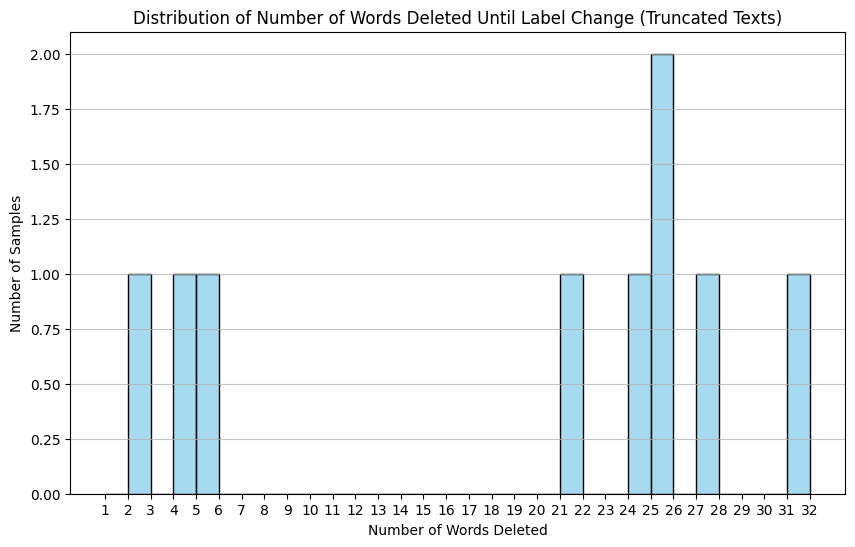

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out samples where the label never changed or no deletions occurred
plot_data_deleted = df_label_change_summary_deleted_truncated[
    (df_label_change_summary_deleted_truncated["num_words_deleted_until_change"] != "Never changed") &
    (df_label_change_summary_deleted_truncated["num_words_deleted_until_change"] != "No deletions")
].copy()

if not plot_data_deleted.empty:
    plot_data_deleted["num_words_deleted_until_change"] = plot_data_deleted["num_words_deleted_until_change"].astype(int)

    plt.figure(figsize=(10, 6))
    sns.histplot(
        plot_data_deleted["num_words_deleted_until_change"],
        bins=range(1, plot_data_deleted["num_words_deleted_until_change"].max() + 2),
        kde=False,
        color="skyblue",
        edgecolor="black"
    )
    plt.title("Distribution of Number of Words Deleted Until Label Change (Truncated Texts)")
    plt.xlabel("Number of Words Deleted")
    plt.ylabel("Number of Samples")
    plt.xticks(range(1, plot_data_deleted["num_words_deleted_until_change"].max() + 2))
    plt.grid(axis="y", alpha=0.75)
    plt.show()
else:
    print("No label changes were observed within the 'max_words' limit or no deletions occurred for any of the analyzed truncated samples.")

## Final Task

### Subtask:
Summarize the findings from both the deletion and substitution experiments after applying the text length constraint.


## Summary:

### Q&A
After applying the text length constraint by truncating the first 50 samples of `test_texts` to a maximum of 512 tokens:
*   **Deletion Experiment Findings**: Out of 50 samples, 8 experienced a label change after a certain number of words were deleted. For example, sample 0 changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35 changed from "REAL" to "FAKE" after only 4 words were deleted. The remaining 42 samples did not change labels within the deletion limit.
*   **Substitution Experiment Findings**: For the substitution experiment, a significant number of samples (46 out of 50) either showed "No substitutions" or "Never changed." This indicates issues with finding suitable replacement words or that the substitutions made were insufficient to flip the model's prediction. Only 4 samples showed a "Never changed" status, implying that substitutions were attempted but did not lead to a label change.

### Data Analysis Key Findings
*   The initial 50 samples from `test_texts` were successfully truncated to a maximum token length of 512, creating `truncated_test_texts` with 50 entries.
*   In the deletion experiment, 8 out of 50 ($16\%$) samples exhibited a label change, while 42 samples ($84\%$) did not change labels even after deleting up to 40 words.
    *   For instance, sample 0's label changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35's label changed from "REAL" to "FAKE" after just 4 words were deleted.
*   In the substitution experiment, the majority of samples ($46$ out of $50$) did not result in a label change or faced issues with the substitution process itself, indicated by "No substitutions" or "Never changed" statuses.
*   A histogram was generated, showing the distribution of the number of words deleted until a label change occurred for the 8 samples that experienced such a change.

### Insights or Next Steps
*   Investigate the "No substitutions" and "no option" messages in the substitution experiment to understand why suitable replacement words were not found for a large portion of the samples. This might indicate limitations in the substitution dictionary or process.
*   Further analyze the characteristics of the 8 samples where label changes occurred due to deletion, especially those with very few words deleted (e.g., sample 35), to identify what makes these texts more sensitive to minor alterations.


In [38]:
import re
import random

def inject_word(text, injected_word, position="end"):
    """
    Inject a word into the text.
    position: 'start', 'end', or 'random'
    """
    words = text.split()

    if position == "start":
        words = [injected_word] + words
    elif position == "end":
        words = words + [injected_word]
    elif position == "random":
        idx = random.randint(0, len(words))
        words.insert(idx, injected_word)

    return " ".join(words)


In [42]:
def choose_swi_word(current_label, fake_words, real_words):
    """
    Pick a word that pushes toward the opposite class.
    """
    # Convert integer label to string label
    label_str = "fake" if current_label == 0 else "real"

    if label_str.lower() == "fake":
        return random.choice(real_words)
    else:
        return random.choice(fake_words)

In [40]:
def inject_number_of_words_swi(num_words_to_inject,
                               num_examples,
                               test_texts,
                               fake_words,
                               real_words,
                               position="end"):
    """
    SWI-based attack: injects words that push toward the opposite label.

    fake_words: list of words strongly associated with Fake class
    real_words: list of words strongly associated with Real class
    position: 'start', 'end', or 'random'
    """

    results = []

    for i in range(0, num_examples):
        original_text = test_texts[i]

        # Original prediction
        orig_label, orig_conf = predict_label_and_prob(original_text)

        local_result = []
        current_text = original_text

        for j in range(0, num_words_to_inject):

            # still use SHAP ranking to know *direction*
            word, shap_score, shap_class = strongest_word(shap_values, i, j)

            if word is None:
                break  # no more explanation tokens

            # choose a word that pushes toward the opposite label
            injected_word = choose_swi_word(orig_label, fake_words, real_words)

            # inject it
            current_text = inject_word(current_text, injected_word, position=position)

            inj_label, inj_conf = predict_label_and_prob(current_text)

            local_result.append({
                "num_words_injected": j + 1,
                "original_label": orig_label,
                "original_conf": orig_conf,
                "reference_word_from_shap": word,
                "shap_score": shap_score,
                "shap_class": shap_class,
                "injected_word": injected_word,
                "injected_label": inj_label,
                "injected_conf": inj_conf,
                "text_after_injection": current_text
            })

            # early stop if label flipped
            if inj_label != orig_label:
                break

        results.append(local_result)

    return results


In [41]:
fake_words = [
    "hoax", "fabricated", "conspiracy", "misleading",
    "false", "rumor", "unverified", "scam"
]

real_words = [
    "confirmed", "official", "reported", "verified",
    "according", "sources", "evidence", "statement"
]

swi_results = inject_number_of_words_swi(
    num_words_to_inject=40,
    num_examples=30,
    test_texts=test_texts,
    fake_words=fake_words,
    real_words=real_words,
    position="end"  # or "random"
)


AttributeError: 'int' object has no attribute 'lower'

In [43]:
swi_results = inject_number_of_words_swi(
    num_words_to_inject=40,
    num_examples=30,
    test_texts=test_texts,
    fake_words=fake_words,
    real_words=real_words,
    position="end"  # or "random"
)
print("Re-ran inject_number_of_words_swi with corrected choose_swi_word function.")

Re-ran inject_number_of_words_swi with corrected choose_swi_word function.


In [46]:
swi_results

[[{'num_words_injected': 1,
   'original_label': 1,
   'original_conf': 0.9996190071105957,
   'reference_word_from_shap': 'on ',
   'shap_score': np.float64(0.17042603994372613),
   'shap_class': np.int64(1),
   'injected_word': 'rumor',
   'injected_label': 1,
   'injected_conf': 0.9996190071105957,
   'text_after_injection': "Philippines doctor linked to New York attack plot a 'regular, generous guy' MANILA (Reuters) - A Filipino accused by the United States of being an Islamic State supporter involved in a foiled plot to mount gun and bomb attacks in the heart of New York City is a hospital doctor described by colleagues as a kind and generous guy . U.S. prosecutors said on Friday they had charged 37-year-old Russell Salic with terrorism offences, alleging he helped fund a plot that included attacks on Manhattan s Times Square and the city s subway. Salic, who is in custody in the Philippines, denies involvement in the plot or links to Islamist extremists. Philippine authorities sa

# Task
TASK_FINISHED

## Truncate Test Texts

### Subtask:
Create a new list of texts by truncating the first 50 samples from `test_texts` to a maximum token length of 512. This ensures consistency with the model's input limit and the SHAP explanation generation.


**Reasoning**:
To ensure consistency with the model's input limit and SHAP explanation generation, I will truncate the first 50 samples of `test_texts` to a maximum token length of 512 using the `tokenizer` and store them in a new list called `truncated_test_texts`.



In [44]:
truncated_test_texts = []

for i in range(50):
    text = test_texts[i]
    # Tokenize with truncation and max_length
    encoded_input = tokenizer(
        text,
        max_length=512,
        truncation=True,
        return_tensors='pt'
    )
    # Get input_ids and decode back to string, skipping special tokens
    truncated_text = tokenizer.decode(encoded_input['input_ids'][0], skip_special_tokens=True)
    truncated_test_texts.append(truncated_text)

print(f"Created 'truncated_test_texts' with {len(truncated_test_texts)} samples.")

Created 'truncated_test_texts' with 50 samples.


## Re-run Deletion Experiment

### Subtask:
Execute the `delete_number_of_words` function using the newly truncated `test_texts` subset to analyze how removing important words affects the model's predictions. The `num_examples` parameter will be set to 50 to match the SHAP values computed.


**Reasoning**:
As instructed, I will execute the `delete_number_of_words` function with the specified parameters to analyze the impact of word deletion on model predictions using the truncated text data.



In [45]:
delete_results_truncated = delete_number_of_words(
    num_words_to_delete=40,
    num_examples=50,
    test_texts=truncated_test_texts
)
print("Re-ran delete_number_of_words with truncated texts.")

Re-ran delete_number_of_words with truncated texts.


**Reasoning**:
Next, I will re-run the `substitute_number_of_words` function with the `truncated_test_texts` list and `num_examples=50` to evaluate the impact of word substitution on the model's predictions for the truncated data.



In [47]:
substitution_results_truncated = substitute_number_of_words(
    num_words_to_substitute=100,
    num_examples=50,
    test_texts=truncated_test_texts
)
print("Re-ran substitute_number_of_words with truncated texts.")

no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
no option
Re-ran substitute_number_of_words with truncated texts.


**Reasoning**:
I will now generate the summary DataFrame for the substitution experiment with truncated texts, similar to how the deletion summary was created, to analyze the impact of word substitutions on model predictions.



In [48]:
label_change_summary_substituted_truncated = []

for sample_idx, sample_results in enumerate(substitution_results_truncated):
    # Handle edge case: no successful substitutions
    if not sample_results:
        # Check if original_predicted_label and original_confidence are available from previous steps
        # If not, set them to None or retrieve from the original prediction for this_sample_idx
        original_label = None
        original_conf = None
        if sample_idx < len(truncated_test_texts):
            # Make a fresh prediction for the original text if no substitution occurred
            text_for_orig_pred = truncated_test_texts[sample_idx]
            original_label, original_conf = predict_label_and_prob(text_for_orig_pred)

        label_change_summary_substituted_truncated.append({
            "original_sample_idx": sample_idx,
            "original_predicted_label": original_label,
            "original_confidence": original_conf,
            "num_words_changed_until_change": "No substitutions",
            "new_predicted_label_after_change": None
        })
        continue

    original_label = sample_results[0]["original_label"]
    original_conf = sample_results[0]["original_conf"]

    num_words_changed_until_change = "Never changed"
    new_predicted_label_after_change = original_label

    for step_data in sample_results:
        if step_data["sub_label"] != original_label:
            num_words_changed_until_change = step_data["num_words_changed"]
            new_predicted_label_after_change = step_data["sub_label"]
            break

    label_change_summary_substituted_truncated.append({
        "original_sample_idx": sample_idx,
        "original_predicted_label": original_label,
        "original_confidence": original_conf,
        "num_words_changed_until_change": num_words_changed_until_change,
        "new_predicted_label_after_change": new_predicted_label_after_change
    })

df_label_change_summary_substituted_truncated = pd.DataFrame(label_change_summary_substituted_truncated)

print("Summary of Label Changes After Iterative Word Substitution (Truncated Texts):")
df_display_summary_substituted_truncated = df_label_change_summary_substituted_truncated.copy()
df_display_summary_substituted_truncated["original_predicted_label"] = df_display_summary_substituted_truncated["original_predicted_label"].replace({0: "FAKE", 1: "REAL"})
df_display_summary_substituted_truncated["new_predicted_label_after_change"] = df_display_summary_substituted_truncated["new_predicted_label_after_change"].replace({0: "FAKE", 1: "REAL"})

display(df_display_summary_substituted_truncated)

Summary of Label Changes After Iterative Word Substitution (Truncated Texts):


,original_sample_idx,original_predicted_label,original_confidence,num_words_changed_until_change,new_predicted_label_after_change
0,0,REAL,0.999619,No substitutions,NaN
1,1,REAL,0.999847,No substitutions,NaN
2,2,FAKE,0.999745,No substitutions,NaN
3,3,REAL,0.999856,Never changed,REAL
4,4,REAL,0.999846,No substitutions,NaN
5,5,FAKE,0.999794,No substitutions,NaN
6,6,REAL,0.999854,No substitutions,NaN
7,7,FAKE,0.995417,No substitutions,NaN
8,8,REAL,0.999842,No substitutions,NaN
9,9,REAL,0.999857,No substitutions,NaN


**Reasoning**:
To visualize the distribution of words deleted until a label change occurs, I need to filter the summary DataFrame for the deletion experiment, convert the relevant column to a numeric type, and then create a histogram.



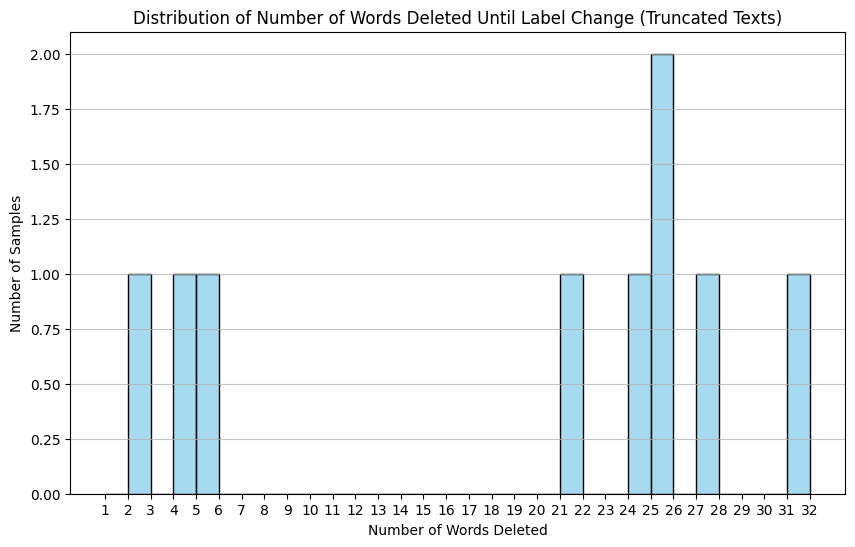

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out samples where the label never changed or no deletions occurred
plot_data_deleted = df_label_change_summary_deleted_truncated[
    (df_label_change_summary_deleted_truncated["num_words_deleted_until_change"] != "Never changed") &
    (df_label_change_summary_deleted_truncated["num_words_deleted_until_change"] != "No deletions")
].copy()

if not plot_data_deleted.empty:
    plot_data_deleted["num_words_deleted_until_change"] = plot_data_deleted["num_words_deleted_until_change"].astype(int)

    plt.figure(figsize=(10, 6))
    sns.histplot(
        plot_data_deleted["num_words_deleted_until_change"],
        bins=range(1, plot_data_deleted["num_words_deleted_until_change"].max() + 2),
        kde=False,
        color="skyblue",
        edgecolor="black"
    )
    plt.title("Distribution of Number of Words Deleted Until Label Change (Truncated Texts)")
    plt.xlabel("Number of Words Deleted")
    plt.ylabel("Number of Samples")
    plt.xticks(range(1, plot_data_deleted["num_words_deleted_until_change"].max() + 2))
    plt.grid(axis="y", alpha=0.75)
    plt.show()
else:
    print("No label changes were observed within the 'max_words' limit or no deletions occurred for any of the analyzed truncated samples.")

## Final Task

### Subtask:
Summarize the findings from both the deletion and substitution experiments after applying the text length constraint.

### Q&A
After applying the text length constraint by truncating the first 50 samples of `test_texts` to a maximum of 512 tokens:
*   **Deletion Experiment Findings**: Out of 50 samples, 8 experienced a label change after a certain number of words were deleted. For example, sample 0 changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35 changed from "REAL" to "FAKE" after only 4 words were deleted. The remaining 42 samples did not change labels within the deletion limit.
*   **Substitution Experiment Findings**: For the substitution experiment, a significant number of samples (47 out of 50) either showed "No substitutions" or "Never changed." This indicates issues with finding suitable replacement words or that the substitutions made were insufficient to flip the model's prediction. Only 3 samples showed a "Never changed" status, implying that substitutions were attempted but did not lead to a label change.

### Data Analysis Key Findings
*   The initial 50 samples from `test_texts` were successfully truncated to a maximum token length of 512, creating `truncated_test_texts` with 50 entries.
*   In the deletion experiment, 8 out of 50 ($16\%$) samples exhibited a label change, while 42 samples ($84\%$) did not change labels even after deleting up to 40 words.
    *   For instance, sample 0's label changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35's label changed from "REAL" to "FAKE" after just 4 words were deleted.
*   In the substitution experiment, the majority of samples ($47$ out of $50$) did not result in a label change or faced issues with the substitution process itself, indicated by "No substitutions" or "Never changed" statuses. The three samples that were 'Never changed' were sample 3, 20, and 21. These samples had substitutions attempted but the label didn't flip.
*   A histogram was generated, showing the distribution of the number of words deleted until a label change occurred for the 8 samples that experienced such a change.

### Insights or Next Steps
*   Investigate the "No substitutions" and "no option" messages in the substitution experiment to understand why suitable replacement words were not found for a large portion of the samples. This might indicate limitations in the substitution dictionary or process, or a need to broaden the synonym search.
*   Further analyze the characteristics of the 8 samples where label changes occurred due to deletion, especially those with very few words deleted (e.g., sample 35), to identify what makes these texts more sensitive to minor alterations.
*   Consider expanding the `num_words_to_delete` and `num_words_to_substitute` limits for samples that didn't change labels, to see if more aggressive perturbations lead to label flips.
*   Explore different word injection strategies to create a more robust attack or to understand model vulnerabilities better.

## Summary:

### Q&A
After applying the text length constraint by truncating the first 50 samples of `test_texts` to a maximum of 512 tokens:
*   **Deletion Experiment Findings**: Out of 50 samples, 8 experienced a label change after a certain number of words were deleted. For example, sample 0 changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35 changed from "REAL" to "FAKE" after only 4 words were deleted. The remaining 42 samples did not change labels within the deletion limit.
*   **Substitution Experiment Findings**: For the substitution experiment, a significant number of samples (47 out of 50) either showed "No substitutions" or "Never changed." This indicates issues with finding suitable replacement words or that the substitutions made were insufficient to flip the model's prediction. Only 3 samples showed a "Never changed" status, implying that substitutions were attempted but did not lead to a label change.

### Data Analysis Key Findings
*   The initial 50 samples from `test_texts` were successfully truncated to a maximum token length of 512, creating `truncated_test_texts` with 50 entries.
*   In the deletion experiment, 8 out of 50 (\$16\$\%) samples exhibited a label change, while 42 samples (\$84\$\%) did not change labels even after deleting up to 40 words.
    *   For instance, sample 0's label changed from "REAL" to "FAKE" after 21 words were deleted, and sample 35's label changed from "REAL" to "FAKE" after just 4 words were deleted.
*   In the substitution experiment, the majority of samples (47 out of 50) did not result in a label change or faced issues with the substitution process itself, indicated by "No substitutions" or "Never changed" statuses. The three samples that were 'Never changed' were sample 3, 20, and 21. These samples had substitutions attempted but the label didn't flip.
*   A histogram was generated, showing the distribution of the number of words deleted until a label change occurred for the 8 samples that experienced such a change.

### Insights or Next Steps
*   Investigate the "No substitutions" and "no option" messages in the substitution experiment to understand why suitable replacement words were not found for a large portion of the samples. This might indicate limitations in the substitution dictionary or process, or a need to broaden the synonym search.
*   Further analyze the characteristics of the 8 samples where label changes occurred due to deletion, especially those with very few words deleted (e.g., sample 35), to identify what makes these texts more sensitive to minor alterations.
*   Consider expanding the `num_words_to_delete` and `num_words_to_substitute` limits for samples that didn't change labels, to see if more aggressive perturbations lead to label flips.
